In [2]:
import pandas as pd
import matplotlib.pyplot as plt
url='https://raw.githubusercontent.com/selva86/datasets/master/a10.csv'
data = pd.read_csv(url)

In [3]:
data['date']= pd.to_datetime(data['date'])

In [4]:
data.set_index('date' ,inplace = True)

In [5]:
data.head()

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869


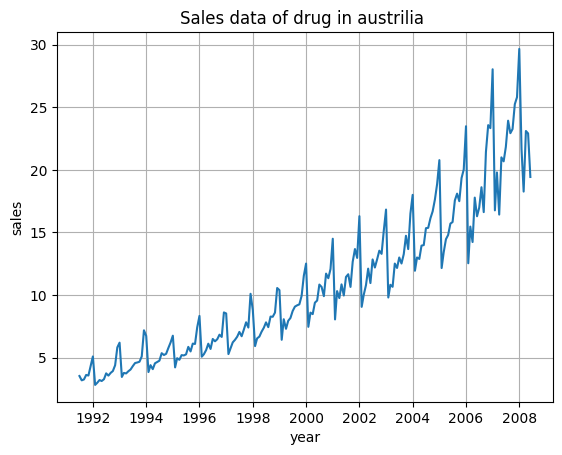

In [6]:
#b

plt.plot(data)
plt.title('Sales data of drug in austrilia ')
plt.xlabel('year')
plt.ylabel('sales')
plt.grid(True)
plt.show()


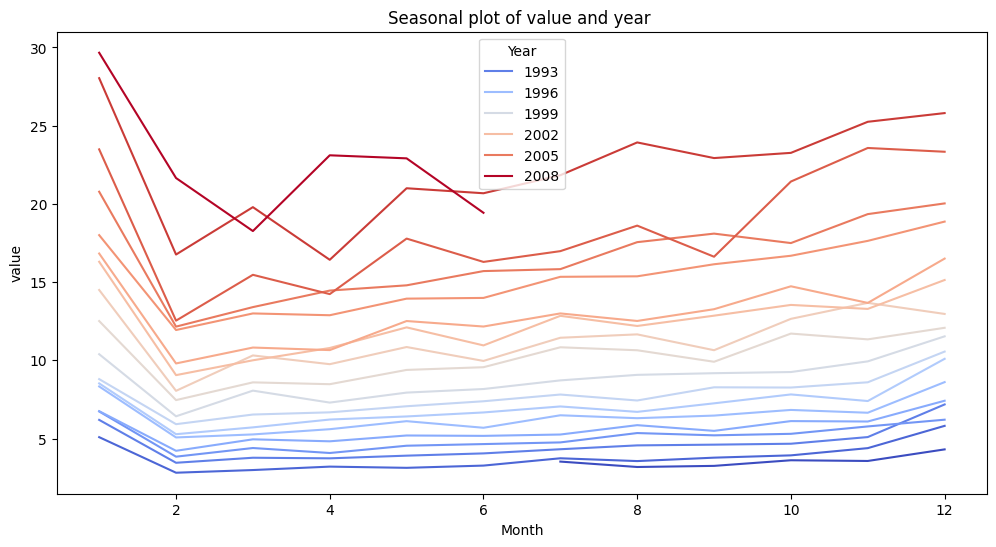

In [7]:
#c

import seaborn as sns

data['Month']=data.index.month
data['Year']=data.index.year
plt.figure(figsize=(12,6))
sns.lineplot(data=data , x='Month',y='value',hue='Year',palette='coolwarm')
plt.title('Seasonal plot of value and year ')
plt.show()

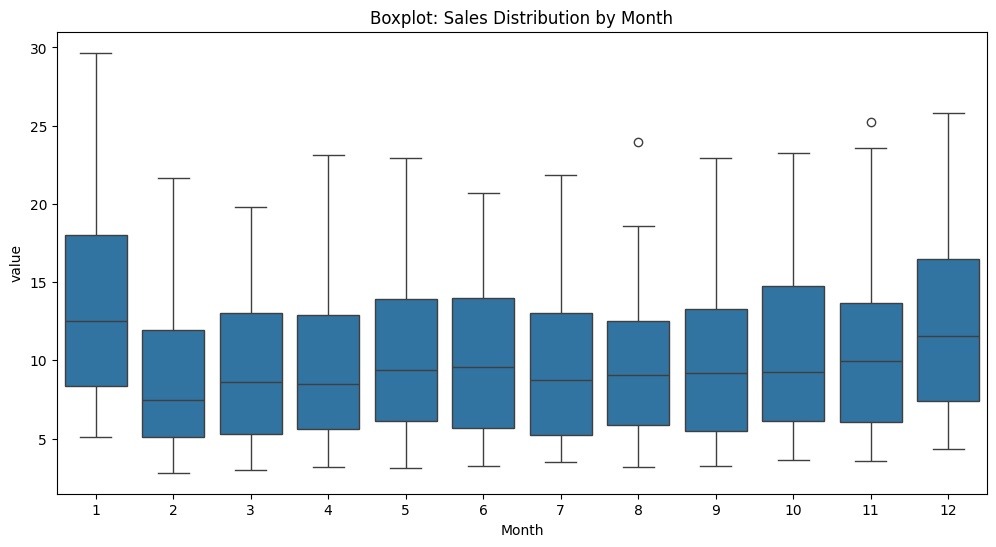

In [8]:
#d
plt.figure(figsize=(12,6))
sns.boxplot(x='Month', y='value', data=data)
plt.title("Boxplot: Sales Distribution by Month")
plt.show()


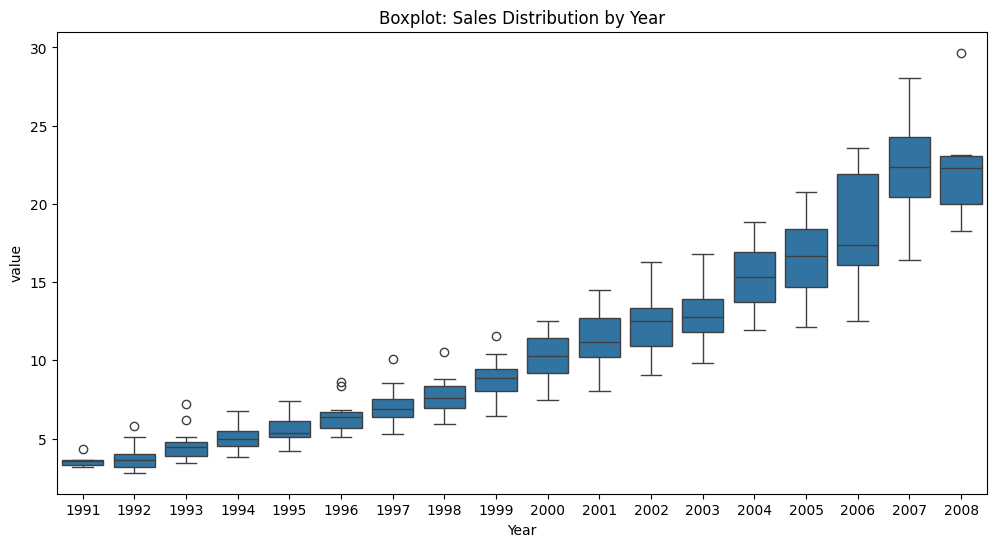

In [9]:
#d
plt.figure(figsize=(12,6))
sns.boxplot(x='Year', y='value', data=data)
plt.title("Boxplot: Sales Distribution by Year")
plt.show()

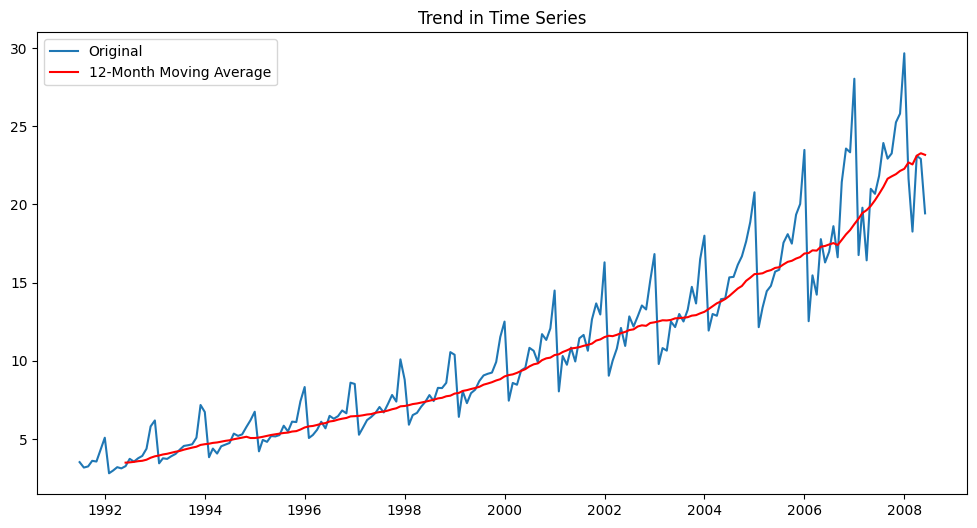

In [10]:
# Plot with rolling average to highlight trend
#e
data['Rolling_Mean'] = data['value'].rolling(window=12).mean()

plt.figure(figsize=(12,6))
plt.plot(data['value'], label='Original')
plt.plot(data['Rolling_Mean'], color='red', label='12-Month Moving Average')
plt.title('Trend in Time Series')
plt.legend()
plt.show()


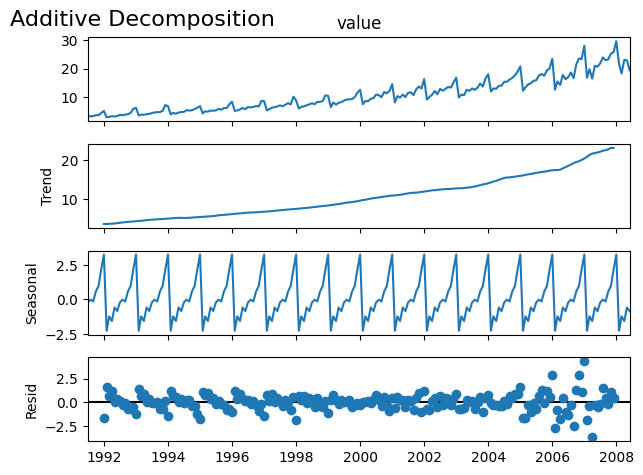

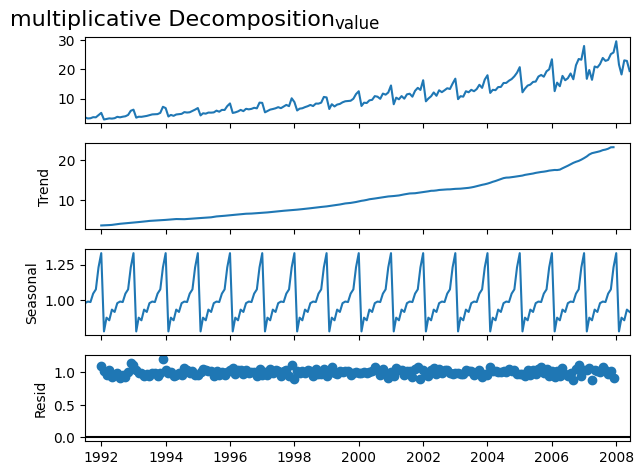

In [15]:
# Additive decomposition
#f
#Additive: Y = Trend + Seasonality + Noise

#Multiplicative: Y = Trend × Seasonality × Noise


#g
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(data['value'], model='additive', period=12)
result.plot()
plt.suptitle("Additive Decomposition", fontsize=16 ,x=0.0,ha='left')
plt.show()




result = seasonal_decompose(data['value'], model='multiplicative', period=12)
result.plot()
plt.suptitle("multiplicative Decomposition", fontsize=16,x=0.0,ha='left')
plt.show()


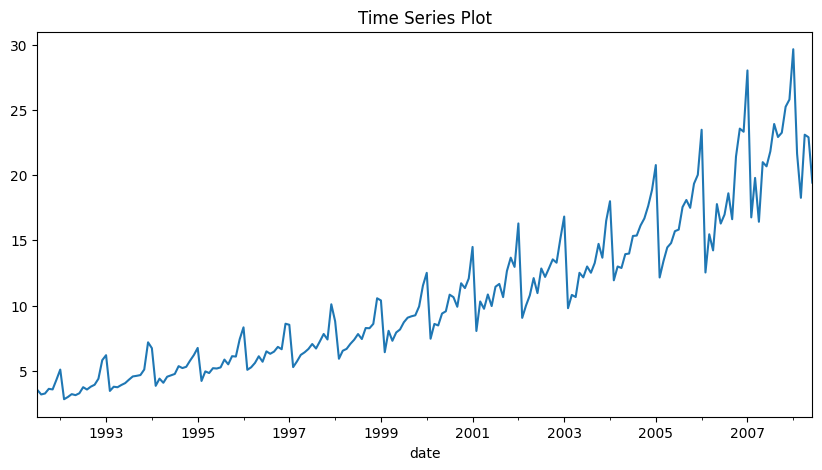

In [21]:
#h stationary or not

# 1st method visual
data['value'].plot(figsize=(10, 5))
plt.title("Time Series Plot")
plt.show()


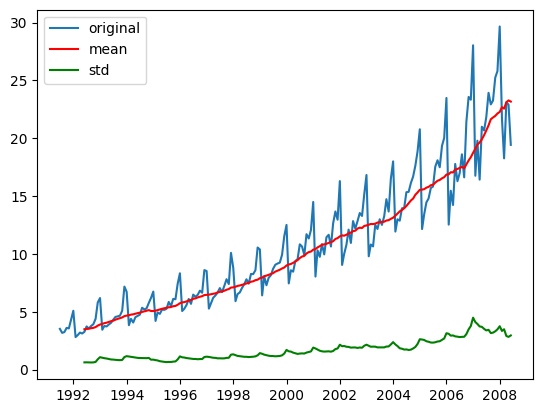

In [26]:

#2nd method rolling mean and std
rolling_mean=data['value'].rolling(window=12).mean()
rolling_std=data['value'].rolling(window=12).std()

plt.plot(data['value'],label='original')
plt.plot(rolling_mean,label='mean',color='red')
plt.plot(rolling_std,label='std',color='green')
plt.legend()
plt.show()

In [28]:
#adf test
from statsmodels.tsa.stattools import adfuller
result=adfuller(data['value'])
print('adf stat :',result[0])
print('p- value :',result[1])

adf stat : 3.14518568930673
p- value : 1.0


In [31]:
#i
data_diff=data['value'].diff().dropna()
result=adfuller(data_diff)
print('adf stat :',result[0])
print('p- value :',result[1])

adf stat : -2.4951721474497393
p- value : 0.11665341686468789


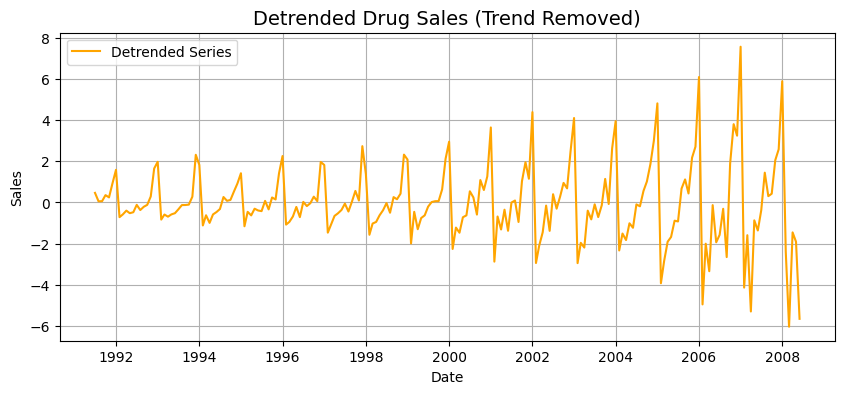

In [32]:
#j
result = seasonal_decompose(data['value'], model='multiplicative', extrapolate_trend='freq')

# Step 3: Detrend by subtracting the trend component
detrended = data['value'] - result.trend

# Step 4: Plot the detrended series
plt.figure(figsize=(10, 4))
plt.plot(detrended, label='Detrended Series', color='orange')
plt.title('Detrended Drug Sales (Trend Removed)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

In [33]:
#k decensolalized

# Decompose (multiplicative model)
result = seasonal_decompose(df['value'], model='multiplicative', extrapolate_trend='freq')

# Deseasonalize by dividing by the seasonal component
deseasonalized = df['value'] / result.seasonal

# Plot
plt.figure(figsize=(10, 4))
plt.plot(deseasonalized, label='Deseasonalized Series', color='teal')
plt.title('Deseasonalized Drug Sales (Seasonality Removed)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Deseasonalized Sales')
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'df' is not defined

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

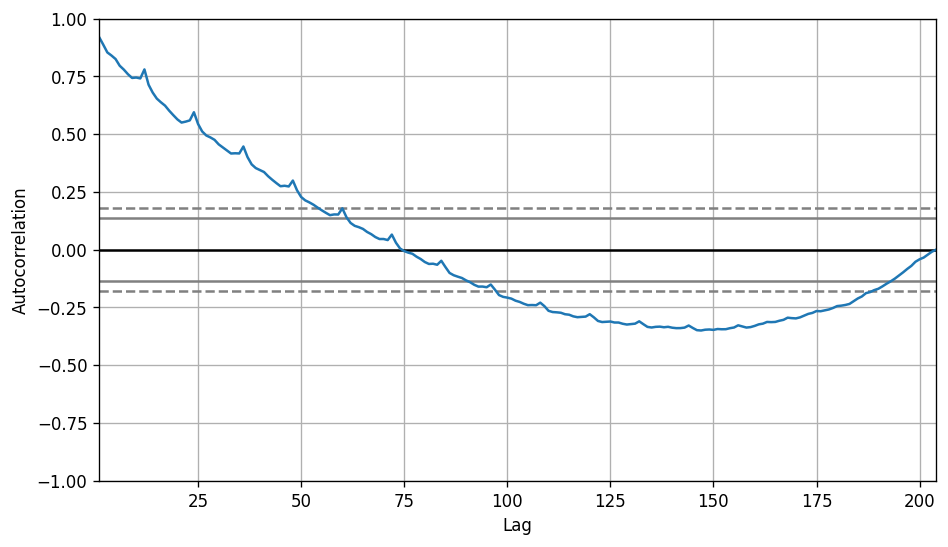

In [35]:
#l
# l. test for seasonality of a time series
from pandas.plotting import autocorrelation_plot  # Import autocorrelation plot from pandas plotting utilities
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/a10.csv')  # Load the dataset

# Draw Plot
plt.rcParams.update({'figure.figsize': (9, 5), 'figure.dpi': 120})  # Update figure size and resolution settings
autocorrelation_plot(df.value.tolist())  # Generate and plot the autocorrelation of the time series data